# Playground for testing scientific code


### A simple motivating example of rotating a line based on GA compared to the traditional methods of matrix multiplication, euler angles, and quaternions.

/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning:

numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.

/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning:

numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.



Rotated Point 1:
Euler Angles:      [0.70710678 0.70710678 0.        ]
Rotation Matrix:   [0.70710678 0.70710678 0.        ]
Quaternions:       [0.70710678 0.70710678 0.        ]
Geometric Algebra: [0.70710678 0.70710678 0.        ]

Rotated Point 2:
Euler Angles:      [-0.70710678  0.70710678  0.        ]
Rotation Matrix:   [-0.70710678  0.70710678  0.        ]
Quaternions:       [-0.70710678  0.70710678  0.        ]
Geometric Algebra: [-0.70710678  0.70710678  0.        ]


/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning:

numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.



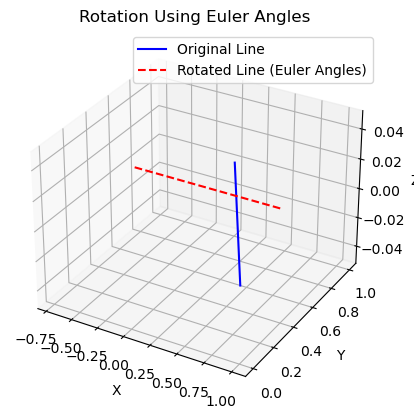

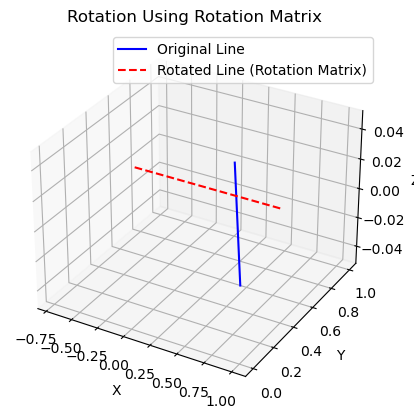

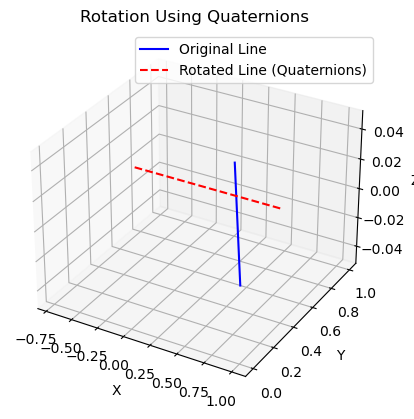

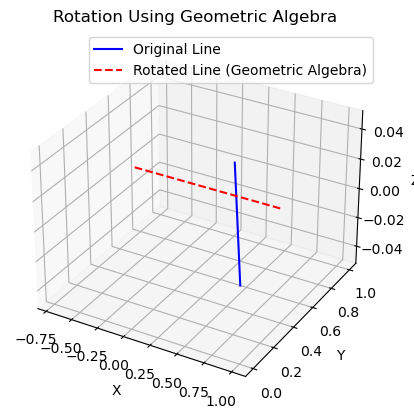

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from clifford import Cl

# Set up 3D plotting
from mpl_toolkits.mplot3d import Axes3D

# Define the original line
point1 = np.array([1, 0, 0])
point2 = np.array([0, 1, 0])
line = point2 - point1

# Rotation parameters
theta = np.deg2rad(45)
axis = np.array([0, 0, 1])

# Euler Angles
def rotate_euler(point, theta):
    Rz = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    return Rz @ point

rotated_point1_euler = rotate_euler(point1, theta)
rotated_point2_euler = rotate_euler(point2, theta)

# Rotation Matrix
def rotate_matrix(point, axis, theta):
    axis = axis / np.linalg.norm(axis)
    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    R = np.eye(3) + np.sin(theta)*K + (1 - np.cos(theta))*(K @ K)
    return R @ point

rotated_point1_matrix = rotate_matrix(point1, axis, theta)
rotated_point2_matrix = rotate_matrix(point2, axis, theta)

# Quaternions
def rotate_quaternion(point, axis, theta):
    axis = axis / np.linalg.norm(axis)
    w = np.cos(theta / 2)
    x, y, z = axis * np.sin(theta / 2)
    q = np.array([w, x, y, z])
    p = np.array([0, *point])
    q_conj = np.array([w, -x, -y, -z])
    temp = quaternion_mult(q, p)
    rotated_p = quaternion_mult(temp, q_conj)
    return rotated_p[1:]

def quaternion_mult(a, b):
    w1, x1, y1, z1 = a
    w2, x2, y2, z2 = b
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    return np.array([w, x, y, z])

rotated_point1_quat = rotate_quaternion(point1, axis, theta)
rotated_point2_quat = rotate_quaternion(point2, axis, theta)

# Geometric Algebra
layout, blades = Cl(3)
e1, e2, e3 = blades['e1'], blades['e2'], blades['e3']

def rotate_geometric_algebra(point, axis, theta):
    # Create vector in GA
    p = point[0]*e1 + point[1]*e2 + point[2]*e3
    
    # Create unit vector for axis in GA
    n = (axis[0]*e1 + axis[1]*e2 + axis[2]*e3).normal()
    
    # Pseudoscalar for 3D space
    I3 = e1 ^ e2 ^ e3
    
    # Bivector representing the plane of rotation (dual of axis)
    B = n * I3  # Plane orthogonal to n
    
    # Construct the rotor with negative sign
    R = np.cos(theta / 2) - B * np.sin(theta / 2)
    
    # Rotate using the sandwich product
    p_rotated = R * p * ~R
    
    # Extract the vector part (grade-1)
    p_rotated_vector = p_rotated(1)
    
    # Correctly extract the components
    components = [float(p_rotated_vector | basis) for basis in [e1, e2, e3]]
    
    return np.array(components)

rotated_point1_ga = rotate_geometric_algebra(point1, axis, theta)
rotated_point2_ga = rotate_geometric_algebra(point2, axis, theta)

# Verification
print("Rotated Point 1:")
print("Euler Angles:     ", rotated_point1_euler)
print("Rotation Matrix:  ", rotated_point1_matrix)
print("Quaternions:      ", rotated_point1_quat)
print("Geometric Algebra:", rotated_point1_ga)

print("\nRotated Point 2:")
print("Euler Angles:     ", rotated_point2_euler)
print("Rotation Matrix:  ", rotated_point2_matrix)
print("Quaternions:      ", rotated_point2_quat)
print("Geometric Algebra:", rotated_point2_ga)

# Visualization
methods = {
    'Euler Angles': (rotated_point1_euler, rotated_point2_euler),
    'Rotation Matrix': (rotated_point1_matrix, rotated_point2_matrix),
    'Quaternions': (rotated_point1_quat, rotated_point2_quat),
    'Geometric Algebra': (rotated_point1_ga, rotated_point2_ga),
}

for method, (rp1, rp2) in methods.items():
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # Original line
    ax.plot(
        [point1[0], point2[0]],
        [point1[1], point2[1]],
        [point1[2], point2[2]],
        'b-', label='Original Line'
    )
    # Rotated line
    ax.plot(
        [rp1[0], rp2[0]],
        [rp1[1], rp2[1]],
        [rp1[2], rp2[2]],
        'r--', label=f'Rotated Line ({method})'
    )
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.title(f'Rotation Using {method}')
    plt.show()

# Right habd viusalization rule (Y up, Z forward and X to the right) 

/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)
/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


Rotated Point 1:
Euler Angles:      [0.70710678 0.70710678 0.        ]
Rotation Matrix:   [0.70710678 0.70710678 0.        ]
Quaternions:       [0.70710678 0.70710678 0.        ]
Geometric Algebra: [0.70710678 0.70710678 0.        ]

Rotated Point 2:
Euler Angles:      [-0.70710678  0.70710678  0.        ]
Rotation Matrix:   [-0.70710678  0.70710678  0.        ]
Quaternions:       [-0.70710678  0.70710678  0.        ]
Geometric Algebra: [-0.70710678  0.70710678  0.        ]


/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


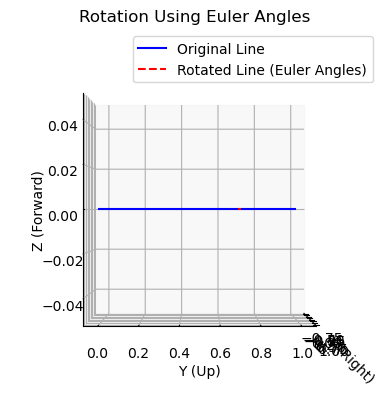

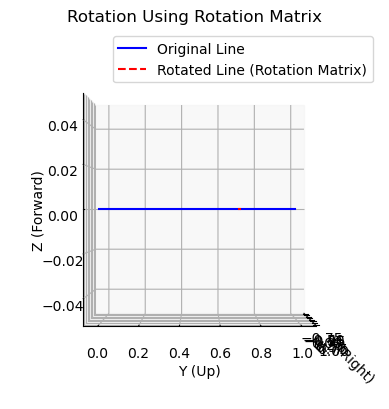

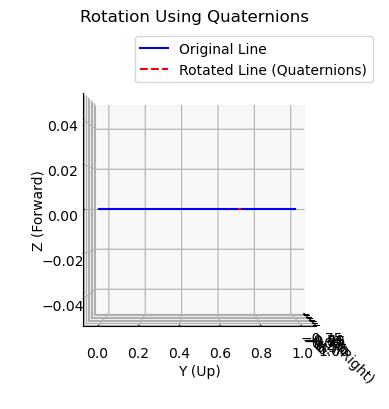

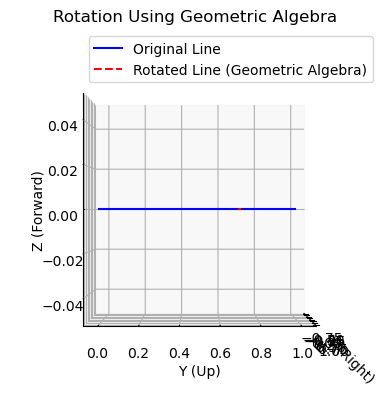

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from clifford import Cl

# Set up 3D plotting
from mpl_toolkits.mplot3d import Axes3D

# Define the original line
point1 = np.array([1, 0, 0])  # Starting point
point2 = np.array([0, 1, 0])  # Ending point
line = point2 - point1

# Rotation parameters
theta = np.deg2rad(45)  # Rotation angle in radians
axis = np.array([0, 0, 1])  # Rotation axis (Z-axis)

# ------------------------------
# Rotation Methods
# ------------------------------

# 1. Euler Angles
def rotate_euler(point, theta):
    Rz = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    return Rz @ point

# 2. Rotation Matrix
def rotate_matrix(point, axis, theta):
    axis = axis / np.linalg.norm(axis)  # Normalize the axis
    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2],  0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    R = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * (K @ K)
    return R @ point

# 3. Quaternions
def rotate_quaternion(point, axis, theta):
    axis = axis / np.linalg.norm(axis)
    w = np.cos(theta / 2)
    x, y, z = axis * np.sin(theta / 2)
    q = np.array([w, x, y, z])  # Rotation quaternion
    p = np.array([0, *point])   # Pure quaternion
    q_conj = np.array([w, -x, -y, -z])  # Conjugate of rotation quaternion
    temp = quaternion_mult(q, p)
    rotated_p = quaternion_mult(temp, q_conj)
    return rotated_p[1:]  # Return vector part

def quaternion_mult(a, b):
    # Quaternion multiplication
    w1, x1, y1, z1 = a
    w2, x2, y2, z2 = b
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    return np.array([w, x, y, z])

# 4. Geometric Algebra
# Initialize geometric algebra
layout, blades = Cl(3)
e1, e2, e3 = blades['e1'], blades['e2'], blades['e3']

def rotate_geometric_algebra(point, axis, theta):
    # Create vector in GA
    p = point[0]*e1 + point[1]*e2 + point[2]*e3

    # Create unit vector for axis in GA
    n = (axis[0]*e1 + axis[1]*e2 + axis[2]*e3).normal()

    # Pseudoscalar for 3D space
    I3 = e1 ^ e2 ^ e3

    # Bivector representing the plane of rotation (dual of axis)
    B = n * I3  # Plane orthogonal to n

    # Construct the rotor with negative sign to match right-hand rule
    R = np.cos(theta / 2) - B * np.sin(theta / 2)

    # Rotate using the sandwich product
    p_rotated = R * p * ~R

    # Extract the vector part (grade-1)
    p_rotated_vector = p_rotated(1)

    # Correctly extract the components
    components = [float(p_rotated_vector | basis) for basis in [e1, e2, e3]]

    return np.array(components)

# ------------------------------
# Compute Rotated Points
# ------------------------------

# Euler Angles
rotated_point1_euler = rotate_euler(point1, theta)
rotated_point2_euler = rotate_euler(point2, theta)

# Rotation Matrix
rotated_point1_matrix = rotate_matrix(point1, axis, theta)
rotated_point2_matrix = rotate_matrix(point2, axis, theta)

# Quaternions
rotated_point1_quat = rotate_quaternion(point1, axis, theta)
rotated_point2_quat = rotate_quaternion(point2, axis, theta)

# Geometric Algebra
rotated_point1_ga = rotate_geometric_algebra(point1, axis, theta)
rotated_point2_ga = rotate_geometric_algebra(point2, axis, theta)

# ------------------------------
# Verification
# ------------------------------

print("Rotated Point 1:")
print("Euler Angles:     ", rotated_point1_euler)
print("Rotation Matrix:  ", rotated_point1_matrix)
print("Quaternions:      ", rotated_point1_quat)
print("Geometric Algebra:", rotated_point1_ga)

print("\nRotated Point 2:")
print("Euler Angles:     ", rotated_point2_euler)
print("Rotation Matrix:  ", rotated_point2_matrix)
print("Quaternions:      ", rotated_point2_quat)
print("Geometric Algebra:", rotated_point2_ga)

# ------------------------------
# Visualization
# ------------------------------

# Prepare data for plotting
methods = {
    'Euler Angles': (rotated_point1_euler, rotated_point2_euler),
    'Rotation Matrix': (rotated_point1_matrix, rotated_point2_matrix),
    'Quaternions': (rotated_point1_quat, rotated_point2_quat),
    'Geometric Algebra': (rotated_point1_ga, rotated_point2_ga),
}

# Visualization with Y-axis up, Z-axis forward, X-axis right
for method, (rp1, rp2) in methods.items():
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Map data to match desired axes orientation
    # X-axis: right, Y-axis: up, Z-axis: forward (into the screen)
    # Invert Z to point forward
    # Original line
    ax.plot(
        [point1[0], point2[0]],    # X coordinates (right)
        [point1[1], point2[1]],    # Y coordinates (up)
        [-point1[2], -point2[2]],  # Z coordinates (forward)
        'b-', label='Original Line'
    )
    # Rotated line
    ax.plot(
        [rp1[0], rp2[0]],          # X coordinates (right)
        [rp1[1], rp2[1]],          # Y coordinates (up)
        [-rp1[2], -rp2[2]],        # Z coordinates (forward)
        'r--', label=f'Rotated Line ({method})'
    )
    # Adjust labels to match the new orientation
    ax.set_xlabel('X (Right)')
    ax.set_ylabel('Y (Up)')
    ax.set_zlabel('Z (Forward)')

    # Set the view so Z is forward
    ax.view_init(elev=0, azim=0)

    # Set aspect ratio for better visualization
    ax.set_box_aspect([1,1,1])  # Equal aspect ratio

    ax.legend()
    plt.title(f'Rotation Using {method}')
    plt.show()

# visualisation with plotly

In [10]:
import numpy as np
from clifford import Cl
import plotly.graph_objects as go

# Define the original line
point1 = np.array([0, 0, 0])  # Starting point
point2 = np.array([1, 0, 0])  # Ending point
line = point2 - point1

# Rotation parameters
theta = np.deg2rad(90)  # Rotation angle in radians
axis = np.array([0, 0, 1])  # Rotation axis (Z-axis)

# ------------------------------
# Rotation Methods
# ------------------------------

# 1. Euler Angles
def rotate_euler(point, theta):
    Rz = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    return Rz @ point

# 2. Rotation Matrix
def rotate_matrix(point, axis, theta):
    axis = axis / np.linalg.norm(axis)  # Normalize the axis
    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2],  0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    R = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * (K @ K)
    return R @ point

# 3. Quaternions
def rotate_quaternion(point, axis, theta):
    axis = axis / np.linalg.norm(axis)
    w = np.cos(theta / 2)
    x, y, z = axis * np.sin(theta / 2)
    q = np.array([w, x, y, z])  # Rotation quaternion
    p = np.array([0, *point])   # Pure quaternion
    q_conj = np.array([w, -x, -y, -z])  # Conjugate of rotation quaternion
    temp = quaternion_mult(q, p)
    rotated_p = quaternion_mult(temp, q_conj)
    return rotated_p[1:]  # Return vector part

def quaternion_mult(a, b):
    # Quaternion multiplication
    w1, x1, y1, z1 = a
    w2, x2, y2, z2 = b
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    return np.array([w, x, y, z])

# 4. Geometric Algebra
# Initialize geometric algebra
layout, blades = Cl(3)
e1, e2, e3 = blades['e1'], blades['e2'], blades['e3']

def rotate_geometric_algebra(point, axis, theta):
    # Create vector in GA
    p = point[0]*e1 + point[1]*e2 + point[2]*e3

    # Create unit vector for axis in GA
    n = (axis[0]*e1 + axis[1]*e2 + axis[2]*e3).normal()

    # Pseudoscalar for 3D space
    I3 = e1 ^ e2 ^ e3

    # Bivector representing the plane of rotation (dual of axis)
    B = n * I3  # Plane orthogonal to n

    # Construct the rotor with negative sign to match right-hand rule
    R = np.cos(theta / 2) - B * np.sin(theta / 2)

    # Rotate using the sandwich product
    p_rotated = R * p * ~R

    # Extract the vector part (grade-1)
    p_rotated_vector = p_rotated(1)

    # Correctly extract the components
    components = [float(p_rotated_vector | basis) for basis in [e1, e2, e3]]

    return np.array(components)

# ------------------------------
# Compute Rotated Points
# ------------------------------

# Euler Angles
rotated_point1_euler = rotate_euler(point1, theta)
rotated_point2_euler = rotate_euler(point2, theta)

# Rotation Matrix
rotated_point1_matrix = rotate_matrix(point1, axis, theta)
rotated_point2_matrix = rotate_matrix(point2, axis, theta)

# Quaternions
rotated_point1_quat = rotate_quaternion(point1, axis, theta)
rotated_point2_quat = rotate_quaternion(point2, axis, theta)

# Geometric Algebra
rotated_point1_ga = rotate_geometric_algebra(point1, axis, theta)
rotated_point2_ga = rotate_geometric_algebra(point2, axis, theta)

# ------------------------------
# Verification
# ------------------------------

print("Rotated Point 1:")
print("Euler Angles:     ", rotated_point1_euler)
print("Rotation Matrix:  ", rotated_point1_matrix)
print("Quaternions:      ", rotated_point1_quat)
print("Geometric Algebra:", rotated_point1_ga)

print("\nRotated Point 2:")
print("Euler Angles:     ", rotated_point2_euler)
print("Rotation Matrix:  ", rotated_point2_matrix)
print("Quaternions:      ", rotated_point2_quat)
print("Geometric Algebra:", rotated_point2_ga)

# ------------------------------
# Visualization with Plotly
# ------------------------------

# Prepare data for plotting
methods = {
    'Euler Angles': (rotated_point1_euler, rotated_point2_euler),
    'Rotation Matrix': (rotated_point1_matrix, rotated_point2_matrix),
    'Quaternions': (rotated_point1_quat, rotated_point2_quat),
    'Geometric Algebra': (rotated_point1_ga, rotated_point2_ga),
}

# Visualization with Y-axis up, Z-axis forward, X-axis right
for method, (rp1, rp2) in methods.items():
    # Original line coordinates
    x_orig = [point1[0], point2[0]]
    y_orig = [point1[1], point2[1]]
    z_orig = [point1[2], point2[2]]  # Z-axis (forward)

    # Rotated line coordinates
    x_rot = [rp1[0], rp2[0]]
    y_rot = [rp1[1], rp2[1]]
    z_rot = [rp1[2], rp2[2]]

    # Create a 3D figure
    fig = go.Figure()

    # Add original line
    fig.add_trace(go.Scatter3d(
        x=x_orig,
        y=y_orig,
        z=z_orig,
        mode='lines',
        line=dict(color='blue', width=5),
        name='Original Line'
    ))

    # Add rotated line
    fig.add_trace(go.Scatter3d(
        x=x_rot,
        y=y_rot,
        z=z_rot,
        mode='lines',
        line=dict(color='red', width=5, dash='dash'),
        name=f'Rotated Line ({method})'
    ))

    # Set axes properties
    fig.update_layout(
        scene=dict(
            xaxis=dict(title='X (Right)'),
            yaxis=dict(title='Y (Up)'),
            zaxis=dict(title='Z (Forward)'),
            aspectmode='data',
            camera=dict(
                eye=dict(x=1.25, y=1.25, z=1.25),  # Set the camera position
                projection=dict(type='perspective')  # Use perspective projection
            )
        ),
        title=f'Rotation Using {method}',
        showlegend=True
    )

    # Show the figure
    fig.show()

/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)
/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)
/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentatio

Rotated Point 1:
Euler Angles:      [0. 0. 0.]
Rotation Matrix:   [0. 0. 0.]
Quaternions:       [0. 0. 0.]
Geometric Algebra: [0. 0. 0.]

Rotated Point 2:
Euler Angles:      [6.123234e-17 1.000000e+00 0.000000e+00]
Rotation Matrix:   [1.11022302e-16 1.00000000e+00 0.00000000e+00]
Quaternions:       [2.22044605e-16 1.00000000e+00 0.00000000e+00]
Geometric Algebra: [2.22044605e-16 1.00000000e+00 0.00000000e+00]


# with colored axes X, Y, Z

In [11]:
import numpy as np
from clifford import Cl
import plotly.graph_objects as go

# Define the original line
point1 = np.array([1, 0, 0])  # Starting point
point2 = np.array([0, 1, 0])  # Ending point
line = point2 - point1

# Rotation parameters
theta = np.deg2rad(45)  # Rotation angle in radians
axis = np.array([0, 0, 1])  # Rotation axis (Z-axis)

# ------------------------------
# Rotation Methods
# ------------------------------

# 1. Euler Angles
def rotate_euler(point, theta):
    Rz = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    return Rz @ point

# 2. Rotation Matrix
def rotate_matrix(point, axis, theta):
    axis = axis / np.linalg.norm(axis)  # Normalize the axis
    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2],  0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    R = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * (K @ K)
    return R @ point

# 3. Quaternions
def rotate_quaternion(point, axis, theta):
    axis = axis / np.linalg.norm(axis)
    w = np.cos(theta / 2)
    x, y, z = axis * np.sin(theta / 2)
    q = np.array([w, x, y, z])  # Rotation quaternion
    p = np.array([0, *point])   # Pure quaternion
    q_conj = np.array([w, -x, -y, -z])  # Conjugate of rotation quaternion
    temp = quaternion_mult(q, p)
    rotated_p = quaternion_mult(temp, q_conj)
    return rotated_p[1:]  # Return vector part

def quaternion_mult(a, b):
    # Quaternion multiplication
    w1, x1, y1, z1 = a
    w2, x2, y2, z2 = b
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    return np.array([w, x, y, z])

# 4. Geometric Algebra
# Initialize geometric algebra
layout, blades = Cl(3)
e1, e2, e3 = blades['e1'], blades['e2'], blades['e3']

def rotate_geometric_algebra(point, axis, theta):
    # Create vector in GA
    p = point[0]*e1 + point[1]*e2 + point[2]*e3

    # Create unit vector for axis in GA
    n = (axis[0]*e1 + axis[1]*e2 + axis[2]*e3).normal()

    # Pseudoscalar for 3D space
    I3 = e1 ^ e2 ^ e3

    # Bivector representing the plane of rotation (dual of axis)
    B = n * I3  # Plane orthogonal to n

    # Construct the rotor with negative sign to match right-hand rule
    R = np.cos(theta / 2) - B * np.sin(theta / 2)

    # Rotate using the sandwich product
    p_rotated = R * p * ~R

    # Extract the vector part (grade-1)
    p_rotated_vector = p_rotated(1)

    # Correctly extract the components
    components = [float(p_rotated_vector | basis) for basis in [e1, e2, e3]]

    return np.array(components)

# ------------------------------
# Compute Rotated Points
# ------------------------------

# Euler Angles
rotated_point1_euler = rotate_euler(point1, theta)
rotated_point2_euler = rotate_euler(point2, theta)

# Rotation Matrix
rotated_point1_matrix = rotate_matrix(point1, axis, theta)
rotated_point2_matrix = rotate_matrix(point2, axis, theta)

# Quaternions
rotated_point1_quat = rotate_quaternion(point1, axis, theta)
rotated_point2_quat = rotate_quaternion(point2, axis, theta)

# Geometric Algebra
rotated_point1_ga = rotate_geometric_algebra(point1, axis, theta)
rotated_point2_ga = rotate_geometric_algebra(point2, axis, theta)

# ------------------------------
# Verification
# ------------------------------

print("Rotated Point 1:")
print("Euler Angles:     ", rotated_point1_euler)
print("Rotation Matrix:  ", rotated_point1_matrix)
print("Quaternions:      ", rotated_point1_quat)
print("Geometric Algebra:", rotated_point1_ga)

print("\nRotated Point 2:")
print("Euler Angles:     ", rotated_point2_euler)
print("Rotation Matrix:  ", rotated_point2_matrix)
print("Quaternions:      ", rotated_point2_quat)
print("Geometric Algebra:", rotated_point2_ga)

# ------------------------------
# Visualization with Plotly
# ------------------------------

# Prepare data for plotting
methods = {
    'Euler Angles': (rotated_point1_euler, rotated_point2_euler),
    'Rotation Matrix': (rotated_point1_matrix, rotated_point2_matrix),
    'Quaternions': (rotated_point1_quat, rotated_point2_quat),
    'Geometric Algebra': (rotated_point1_ga, rotated_point2_ga),
}

# Length of the axes lines
axis_length = 1.5  # Adjust as needed

# Visualization with Y-axis up, Z-axis forward, X-axis right
for method, (rp1, rp2) in methods.items():
    # Original line coordinates
    x_orig = [point1[0], point2[0]]
    y_orig = [point1[1], point2[1]]
    z_orig = [point1[2], point2[2]]  # Z-axis (forward)

    # Rotated line coordinates
    x_rot = [rp1[0], rp2[0]]
    y_rot = [rp1[1], rp2[1]]
    z_rot = [rp1[2], rp2[2]]

    # Create a 3D figure
    fig = go.Figure()

    # Add original line
    fig.add_trace(go.Scatter3d(
        x=x_orig,
        y=y_orig,
        z=z_orig,
        mode='lines',
        line=dict(color='blue', width=5),
        name='Original Line'
    ))

    # Add rotated line
    fig.add_trace(go.Scatter3d(
        x=x_rot,
        y=y_rot,
        z=z_rot,
        mode='lines',
        line=dict(color='red', width=5, dash='dash'),
        name=f'Rotated Line ({method})'
    ))

    # Add X-axis in red
    fig.add_trace(go.Scatter3d(
        x=[0, axis_length],
        y=[0, 0],
        z=[0, 0],
        mode='lines',
        line=dict(color='red', width=2),
        name='X-axis'
    ))

    # Add Y-axis in green
    fig.add_trace(go.Scatter3d(
        x=[0, 0],
        y=[0, axis_length],
        z=[0, 0],
        mode='lines',
        line=dict(color='green', width=2),
        name='Y-axis'
    ))

    # Add Z-axis in blue
    fig.add_trace(go.Scatter3d(
        x=[0, 0],
        y=[0, 0],
        z=[0, axis_length],
        mode='lines',
        line=dict(color='blue', width=2),
        name='Z-axis'
    ))

    # Set axes properties
    fig.update_layout(
        scene=dict(
            xaxis=dict(title='X (Right)', range=[-1.5, 1.5], showbackground=False, showgrid=False),
            yaxis=dict(title='Y (Up)', range=[-0.5, 1.5], showbackground=False, showgrid=False),
            zaxis=dict(title='Z (Forward)', range=[-0.5, 1.5], showbackground=False, showgrid=False),
            aspectmode='data',
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5),  # Set the camera position
                projection=dict(type='perspective')  # Use perspective projection
            )
        ),
        title=f'Rotation Using {method}',
        showlegend=True
    )

    # Show the figure
    fig.show()

/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning:

numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.

/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning:

numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.



Rotated Point 1:
Euler Angles:      [0.70710678 0.70710678 0.        ]
Rotation Matrix:   [0.70710678 0.70710678 0.        ]
Quaternions:       [0.70710678 0.70710678 0.        ]
Geometric Algebra: [0.70710678 0.70710678 0.        ]

Rotated Point 2:
Euler Angles:      [-0.70710678  0.70710678  0.        ]
Rotation Matrix:   [-0.70710678  0.70710678  0.        ]
Quaternions:       [-0.70710678  0.70710678  0.        ]
Geometric Algebra: [-0.70710678  0.70710678  0.        ]


/Users/papagian/opt/anaconda3/envs/elementsProject/lib/python3.8/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning:

numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.

